<a href="https://colab.research.google.com/github/Dyani99/MSBD-570---Final-Project-/blob/main/Data_Visualization_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
download_dir = "/content/downloaded_physionet_data"

In [ ]:
pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you h

In [ ]:
download_dir = "/content/downloaded_physionet_data"

In [ ]:
download_dir = "/content/downloaded_physionet_data"

In [ ]:
import requests
import pandas as pd
import io

# Base URL for the PhysioNet project
# Corrected base URL to point to the raw files directory
physionet_base_url = "https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/"

# Specific file path for Subject1_0cmH2O_normal data
file_path = "Inline_PQ_Data/Subject1_0cmH2O_normal.txt"
full_url = physionet_base_url + file_path

print(f"Attempting to download data from: {full_url}")

try:
    response = requests.get(full_url)
    response.raise_for_status() # Raise an exception for HTTP errors

    # Read the content into a pandas DataFrame
    # Using regex for one or more whitespace characters as separator, common for .txt files
    # Added 'comment='#' to skip lines starting with '#', which are usually metadata.
    df_physionet = pd.read_csv(io.StringIO(response.text), sep='\s+', engine='python', comment='#')

    print("Data downloaded and loaded successfully!")
    display(df_physionet.head())
    print(f"DataFrame shape: {df_physionet.shape}")
except requests.exceptions.RequestException as e:
    print(f"Error downloading file: {e}")
    print("Please ensure the URL is correct and the file exists.")
except pd.errors.ParserError as e:
    print(f"Error parsing the data into a DataFrame: {e}")
    print("The file format might not be whitespace-separated or has other parsing issues. Please inspect the file content.")

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2121/3111726266.py:22: SyntaxWarning: invalid escape sequence '\s'
  df_physionet = pd.read_csv(io.StringIO(response.text), sep='\s+', engine='python', comment='#')


Attempting to download data from: https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/Inline_PQ_Data/Subject1_0cmH2O_normal.txt
Error downloading file: 404 Client Error: Not Found for url: https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/Inline_PQ_Data/Subject1_0cmH2O_normal.txt
Please ensure the URL is correct and the file exists.


In [ ]:
import wfdb

project_name = 'respiratory-oximetry-apnoea/1.0.0'

print(f"Listing records in project: {project_name}")

try:
    # Attempt to get a list of records in the project directory
    record_list = wfdb.io.get_record_list(project_name)
    if record_list:
        print(f"Found {len(record_list)} records:")
        for record in record_list[:10]: # Print first 10 for brevity
            print(record)
        if len(record_list) > 10:
            print("...")
    else:
        print("No records found using wfdb.io.get_record_list.")

    print(f"\nListing annotators in project: {project_name}")
    # Attempt to get a list of annotators (often corresponds to different file types or subdirectories)
    annotator_list = wfdb.io.get_annotator_list(project_name)
    if annotator_list:
        print(f"Found {len(annotator_list)} annotators (which can indicate other file types/subdirectories):")
        for annotator in annotator_list[:10]: # Print first 10 for brevity
            print(annotator)
        if len(annotator_list) > 10:
            print("...")
    else:
        print("No annotators found using wfdb.io.get_annotator_list.")

except Exception as e:
    print(f"Error listing files using wfdb: {e}")
    print("This might mean the directory structure or file types are not standard WFDB format, and we may need to browse the PhysioNet website directly or use requests to list files.")

Listing records in project: respiratory-oximetry-apnoea/1.0.0
Error listing files using wfdb: The database https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0 has no WFDB files to download
This might mean the directory structure or file types are not standard WFDB format, and we may need to browse the PhysioNet website directly or use requests to list files.


In [ ]:
import requests
from bs4 import BeautifulSoup
import os

project_url = "https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/"

def list_files_in_physionet_dir(url, base_path=""):
    file_list = []
    print(f"Fetching directory listing from: {url}")
    try:
        response = requests.get(url)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, 'html.parser')

        # Find all links in the directory listing
        for link in soup.find_all('a'):
            href = link.get('href')
            if href and href != '../': # Ignore parent directory link
                full_path = os.path.join(base_path, href).lstrip('/')
                if href.endswith('/'): # It's a subdirectory
                    print(f"Found subdirectory: {full_path}")
                    # Recursively list files in subdirectory
                    file_list.extend(list_files_in_physionet_dir(url + href, full_path))
                else: # It's a file
                    print(f"Found file: {full_path}")
                    file_list.append(full_path)
    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL {url}: {e}")
    return file_list

all_files = list_files_in_physionet_dir(project_url)

if all_files:
    print(f"\nSuccessfully found {len(all_files)} files in the project.")
    print("First 10 files:")
    for f in all_files[:10]:
        print(f)
    if len(all_files) > 10:
        print("...")
else:
    print("No files found in the project.")


Fetching directory listing from: https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/
Found subdirectory: Code/
Fetching directory listing from: https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/Code/
Found file: Code/DataCollection_InlineSensor.m
Found file: Code/Figure1.jpg
Found file: Code/Figure2.jpg
Found file: Code/Plotting_Code.m
Found file: Code/natsort.m
Found subdirectory: Inline_PQ_Data/
Fetching directory listing from: https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/Inline_PQ_Data/
Found subdirectory: Inline_PQ_Data/Subject1/
Fetching directory listing from: https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/Inline_PQ_Data/Subject1/
Found file: Inline_PQ_Data/Subject1/Subject1_0cmH2O_normal.csv
Found file: Inline_PQ_Data/Subject1/Subject1_4cmH2O_apnea1.csv
Found file: Inline_PQ_Data/Subject1/Subject1_4cmH2O_apnea2.csv
Found file: Inline_PQ_Data/Subject1/Subject1_4cmH2O_normal.csv
Found file: Inline_PQ_Data/Subject1/Subject1_8cm

In [ ]:
import requests
import os

download_dir = "/content/downloaded_physionet_data"
os.makedirs(download_dir, exist_ok=True)

print(f"Starting download of {len(all_files)} files to {download_dir}...")

for i, file_path in enumerate(all_files):
    full_url = project_url + file_path
    local_file_path = os.path.join(download_dir, file_path)

    # Ensure the local subdirectory exists
    os.makedirs(os.path.dirname(local_file_path), exist_ok=True)

    try:
        print(f"[{i+1}/{len(all_files)}] Downloading {file_path} from {full_url}")
        response = requests.get(full_url, stream=True)
        response.raise_for_status() # Raise an exception for HTTP errors

        with open(local_file_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Successfully downloaded: {local_file_path}")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading {file_path}: {e}")
    except Exception as e:
        print(f"An unexpected error occurred while processing {file_path}: {e}")

print("\nDownload process complete.")
print(f"All files are saved in the directory: {download_dir}")


Starting download of 308 files to /content/downloaded_physionet_data...
[1/308] Downloading Code/DataCollection_InlineSensor.m from https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/Code/DataCollection_InlineSensor.m
Successfully downloaded: /content/downloaded_physionet_data/Code/DataCollection_InlineSensor.m
[2/308] Downloading Code/Figure1.jpg from https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/Code/Figure1.jpg
Successfully downloaded: /content/downloaded_physionet_data/Code/Figure1.jpg
[3/308] Downloading Code/Figure2.jpg from https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/Code/Figure2.jpg
Successfully downloaded: /content/downloaded_physionet_data/Code/Figure2.jpg
[4/308] Downloading Code/Plotting_Code.m from https://physionet.org/files/respiratory-oximetry-apnoea/1.0.0/Code/Plotting_Code.m
Successfully downloaded: /content/downloaded_physionet_data/Code/Plotting_Code.m
[5/308] Downloading Code/natsort.m from https://physionet.org/files/re

In [ ]:
import pandas as pd
import os

# Define the path to one of the downloaded CSV files
sample_file_path = os.path.join(download_dir, "Inline_PQ_Data/Subject1/Subject1_0cmH2O_normal.csv")

print(f"Loading sample file: {sample_file_path}")

try:
    # Load the CSV file into a pandas DataFrame
    df_sample = pd.read_csv(sample_file_path)

    print("Sample file loaded successfully.")
    print("Column names:")
    for col in df_sample.columns:
        print(f"- {col}")

    print("\nFirst 5 rows of the sample DataFrame:")
    display(df_sample.head())

except FileNotFoundError:
    print(f"Error: The file {sample_file_path} was not found. Please ensure all files were downloaded correctly.")
except Exception as e:
    print(f"An error occurred while loading or processing the sample file: {e}")

Loading sample file: /content/downloaded_physionet_data/Inline_PQ_Data/Subject1/Subject1_0cmH2O_normal.csv
Sample file loaded successfully.
Column names:
- Time [s]
- Gauge Pressure [cmH2O]
- Inspiratory differential pressure [cmH2O]

First 5 rows of the sample DataFrame:


,Time [s],Gauge Pressure [cmH2O],Inspiratory differential pressure [cmH2O]
0,0.000000,-0.10,0.03
1,0.002573,0.00,0.07
2,0.006792,-0.10,0.03
3,0.010079,-0.06,0.05
4,0.012563,-0.06,0.03


In [ ]:
import re

# Extract the subject ID from the sample_file_path
# The regex looks for 'Subject' followed by one or more digits.
match = re.search(r'Subject(\d+)', sample_file_path)
if match:
    subject_id = f"Subject{match.group(1)}"
    print(f"Created Subject ID: {subject_id}")
else:
    subject_id = None
    print("Could not extract Subject ID from the file path.")


Created Subject ID: Subject1


In [ ]:
import re

unique_subject_ids = set()

for file_path in all_files:
    # The regex looks for 'Subject' followed by one or more digits.
    match = re.search(r'Subject(\d+)', file_path)
    if match:
        subject_id = f"Subject{match.group(1)}"
        unique_subject_ids.add(subject_id)

if unique_subject_ids:
    print("Unique Subject IDs found:")
    for subject_id in sorted(list(unique_subject_ids)):
        print(subject_id)
else:
    print("No Subject IDs found in the downloaded files.")

Unique Subject IDs found:
Subject1
Subject10
Subject11
Subject12
Subject13
Subject14
Subject15
Subject16
Subject17
Subject18
Subject19
Subject2
Subject20
Subject3
Subject4
Subject5
Subject6
Subject7
Subject8
Subject9


In [ ]:
import pandas as pd
import numpy as np
import os
import re

def extract_features(df, signal_cols):
    """
    Extracts a set of statistical features from specified signal columns in a DataFrame.
    """
    features = {}
    for col in signal_cols:
        # Basic statistics
        features[f'{col}_mean'] = df[col].mean()
        features[f'{col}_std'] = df[col].std()
        features[f'{col}_min'] = df[col].min()
        features[f'{col}_max'] = df[col].max()
        features[f'{col}_median'] = df[col].median()
        features[f'{col}_variance'] = df[col].var()
        features[f'{col}_skew'] = df[col].skew()
        features[f'{col}_kurtosis'] = df[col].kurtosis()
        features[f'{col}_peak_to_peak'] = df[col].max() - df[col].min()
        features[f'{col}_rms'] = np.sqrt(np.mean(df[col]**2))

    return features

# List to store features for all files
all_extracted_features = []

# Columns to extract features from
signal_columns = ['Gauge Pressure [cmH2O]', 'Inspiratory differential pressure [cmH2O]']

print("Starting feature extraction...")

# Filter for relevant files (e.g., only Inline_PQ_Data CSVs)
inline_pq_files = [f for f in all_files if f.startswith('Inline_PQ_Data/') and f.endswith('.csv')]

for i, file_path in enumerate(inline_pq_files):
    local_file_path = os.path.join(download_dir, file_path)

    # Extract metadata from filename
    # Example: Inline_PQ_Data/Subject1/Subject1_0cmH2O_normal.csv
    parts = file_path.split('/')
    subject_id_match = re.search(r'Subject(\d+)', parts[1]) # Corrected index from parts[2] to parts[1]
    subject_id = f"Subject{subject_id_match.group(1)}" if subject_id_match else 'Unknown'

    filename_stem = os.path.splitext(parts[2])[0] # Corrected index from parts[3] to parts[2]
    condition_match = re.search(r'(\d+cmH2O)_(\w+)', filename_stem)
    pressure = condition_match.group(1) if condition_match else 'Unknown'
    condition_type = condition_match.group(2) if condition_match else 'Unknown'

    try:
        df = pd.read_csv(local_file_path)
        file_features = extract_features(df, signal_columns)

        # Add metadata to features
        file_features['subject_id'] = subject_id
        file_features['pressure'] = pressure
        file_features['condition_type'] = condition_type
        file_features['original_filename'] = file_path

        all_extracted_features.append(file_features)
        if (i + 1) % 50 == 0 or (i + 1) == len(inline_pq_files):
            print(f"Processed {i+1}/{len(inline_pq_files)} files.")

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Convert the list of feature dictionaries to a DataFrame
df_features = pd.DataFrame(all_extracted_features)

print("\nFeature extraction complete.")
print(f"Created a feature DataFrame with shape: {df_features.shape}")
display(df_features.head())

Starting feature extraction...
Processed 50/140 files.
Processed 100/140 files.
Processed 140/140 files.

Feature extraction complete.
Created a feature DataFrame with shape: (140, 24)


,Gauge Pressure [cmH2O]_mean,Gauge Pressure [cmH2O]_std,Gauge Pressure [cmH2O]_min,Gauge Pressure [cmH2O]_max,Gauge Pressure [cmH2O]_median,Gauge Pressure [cmH2O]_variance,Gauge Pressure [cmH2O]_skew,Gauge Pressure [cmH2O]_kurtosis,Gauge Pressure [cmH2O]_peak_to_peak,Gauge Pressure [cmH2O]_rms,...,Inspiratory differential pressure [cmH2O]_median,Inspiratory differential pressure [cmH2O]_variance,Inspiratory differential pressure [cmH2O]_skew,Inspiratory differential pressure [cmH2O]_kurtosis,Inspiratory differential pressure [cmH2O]_peak_to_peak,Inspiratory differential pressure [cmH2O]_rms,subject_id,pressure,condition_type,original_filename
0,-0.039046,0.157182,-0.85,0.76,0.00,0.024706,-0.506905,3.467608,1.61,0.161956,...,0.04,0.000579,-0.290117,-1.171392,0.12,0.040048,Subject1,0cmH2O,normal,Inline_PQ_Data/Subject1/Subject1_0cmH2O_normal...
1,2.533714,1.879277,0.00,8.46,3.65,3.531681,-0.344493,-1.097592,8.46,3.154564,...,0.05,0.164741,1.965284,2.371610,1.55,0.465696,Subject1,4cmH2O,apnea1,Inline_PQ_Data/Subject1/Subject1_4cmH2O_apnea1...
2,2.536226,1.881844,0.00,8.12,3.68,3.541338,-0.345236,-1.123369,8.12,3.158110,...,0.06,0.181895,2.096060,2.740856,1.71,0.483956,Subject1,4cmH2O,apnea2,Inline_PQ_Data/Subject1/Subject1_4cmH2O_apnea2...
3,2.632432,2.165442,0.00,10.79,3.47,4.689141,0.376715,0.094103,10.79,3.408619,...,0.05,0.280472,1.374503,0.149179,1.85,0.624490,Subject1,4cmH2O,normal,Inline_PQ_Data/Subject1/Subject1_4cmH2O_normal...
4,5.151464,3.665712,0.00,11.10,7.53,13.437442,-0.664069,-1.492127,11.10,6.322545,...,0.07,0.174094,1.908590,2.441790,1.98,0.490028,Subject1,8cmH2O,apnea1,Inline_PQ_Data/Subject1/Subject1_8cmH2O_apnea1...


Now, let's extract features from the Neck Pulse Oximeter data. First, we need to identify the relevant files and inspect a sample to understand its structure and column names.

In [ ]:
import pandas as pd
import os

# Filter for relevant files (e.g., only Neck_Pulse_Oximeter_Data CSVs)
neck_pulse_files = [f for f in all_files if f.startswith('Neck_Pulse_Oximeter_Data/') and f.endswith('.csv')]

if neck_pulse_files:
    # Define the path to one of the downloaded CSV files from Neck Pulse Oximeter Data
    sample_neck_file_path = os.path.join(download_dir, neck_pulse_files[0])

    print(f"Loading sample Neck Pulse Oximeter file: {sample_neck_file_path}")

    try:
        # Load the CSV file into a pandas DataFrame
        df_neck_sample = pd.read_csv(sample_neck_file_path)

        print("Sample Neck Pulse Oximeter file loaded successfully.")
        print("Column names:")
        for col in df_neck_sample.columns:
            print(f"- {col}")

        print("\nFirst 5 rows of the sample Neck Pulse Oximeter DataFrame:")
        display(df_neck_sample.head())

    except FileNotFoundError:
        print(f"Error: The file {sample_neck_file_path} was not found. Please ensure all files were downloaded correctly.")
    except Exception as e:
        print(f"An error occurred while loading or processing the sample Neck Pulse Oximeter file: {e}")
else:
    print("No Neck Pulse Oximeter data files found.")

Loading sample Neck Pulse Oximeter file: /content/downloaded_physionet_data/Neck_Pulse_Oximeter_Data/Subject1/Subject1_0cmH2O_normal_pulse.csv
Sample Neck Pulse Oximeter file loaded successfully.
Column names:
- Time [s]
- PD1
- PD2
- PD3
- PD4
- PD1_9
- PD2_9
- PD3_9
- PD4_9

First 5 rows of the sample Neck Pulse Oximeter DataFrame:


,Time [s],PD1,PD2,PD3,PD4,PD1_9,PD2_9,PD3_9,PD4_9
0,0.000,2.23652,2.37188,2.45244,0.42861,0.93457,0.97324,0.97969,0.58652
1,0.004,2.23652,2.38477,2.47178,0.42861,0.92490,0.97646,0.98291,0.58652
2,0.008,2.22363,2.39121,2.47178,0.42861,0.91846,0.97002,0.98291,0.58652
3,0.012,2.21074,2.39121,2.46855,0.42861,0.90879,0.96680,0.98291,0.58652
4,0.016,2.23008,2.35898,2.47500,0.42861,0.93457,0.95713,0.97969,0.58652


Based on the sample file, the signal columns for Neck Pulse Oximeter data are likely 'Heart Rate [bpm]' and 'SpO2 [%]'. We'll now extract features from all Neck Pulse Oximeter files.

In [ ]:
import pandas as pd
import numpy as np
import os
import re

# List to store features for all Neck Pulse Oximeter files
all_extracted_neck_features = []

# Columns to extract features from for oximetry data
neck_signal_columns = ['PD1', 'PD2'] # Corrected signal column names based on df_neck inspection

print("Starting feature extraction for Neck Pulse Oximeter data...")

# Filter for relevant files (e.g., only Neck_Pulse_Oximeter_Data CSVs)
neck_pulse_files = [f for f in all_files if f.startswith('Neck_Pulse_Oximeter_Data/') and f.endswith('.csv')]

for i, file_path in enumerate(neck_pulse_files):
    local_file_path = os.path.join(download_dir, file_path)

    # Extract metadata from filename
    # Example: Neck_Pulse_Oximeter_Data/Subject1/Subject1_0cmH2O_normal_pulse.csv
    parts = file_path.split('/')
    subject_id_match = re.search(r'Subject(\d+)', parts[1])
    subject_id = f"Subject{subject_id_match.group(1)}" if subject_id_match else 'Unknown'

    filename_stem = os.path.splitext(parts[2])[0]
    # The oximetry files have '_pulse' suffix, need to adjust regex to capture actual condition
    condition_match = re.search(r'(\d+cmH2O)_(\w+)_pulse', filename_stem)
    if not condition_match: # Handle 'Baseline' files or normal files without 'cmH2O' prefix
        condition_match = re.search(r'Subject\d+_(\w+)_pulse', filename_stem)
        if condition_match and condition_match.group(1) == 'Baseline':
            pressure = 'Baseline'
            condition_type = 'Baseline'
        elif condition_match:
            pressure = 'Unknown'
            condition_type = condition_match.group(1) # e.g., 'normal', 'apnea1'
        else:
            pressure = 'Unknown'
            condition_type = 'Unknown'
    else:
        pressure = condition_match.group(1)
        condition_type = condition_match.group(2)

    try:
        df_neck = pd.read_csv(local_file_path)
        # Ensure required columns exist before extracting features
        if all(col in df_neck.columns for col in neck_signal_columns):
            file_neck_features = extract_features(df_neck, neck_signal_columns)

            # Add metadata to features
            file_neck_features['subject_id'] = subject_id
            file_neck_features['pressure'] = pressure
            file_neck_features['condition_type'] = condition_type
            file_neck_features['original_filename'] = file_path

            all_extracted_neck_features.append(file_neck_features)
            if (i + 1) % 50 == 0 or (i + 1) == len(neck_pulse_files):
                print(f"Processed {i+1}/{len(neck_pulse_files)} Neck Pulse Oximeter files.")
        else:
            print(f"Skipping {file_path}: Missing one or more required signal columns ({', '.join(neck_signal_columns)}).")

    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Convert the list of feature dictionaries to a DataFrame
df_neck_features = pd.DataFrame(all_extracted_neck_features)

print("\nNeck Pulse Oximeter Feature extraction complete.")
print(f"Created a Neck Pulse Oximeter feature DataFrame with shape: {df_neck_features.shape}")
display(df_neck_features.head())

Starting feature extraction for Neck Pulse Oximeter data...
Processed 50/160 Neck Pulse Oximeter files.
Processed 100/160 Neck Pulse Oximeter files.
Processed 150/160 Neck Pulse Oximeter files.
Processed 160/160 Neck Pulse Oximeter files.

Neck Pulse Oximeter Feature extraction complete.
Created a Neck Pulse Oximeter feature DataFrame with shape: (160, 24)


,PD1_mean,PD1_std,PD1_min,PD1_max,PD1_median,PD1_variance,PD1_skew,PD1_kurtosis,PD1_peak_to_peak,PD1_rms,...,PD2_median,PD2_variance,PD2_skew,PD2_kurtosis,PD2_peak_to_peak,PD2_rms,subject_id,pressure,condition_type,original_filename
0,2.126340,0.259986,1.55654,2.44922,2.17207,0.067593,-0.467183,-1.083065,0.89268,2.142174,...,2.41699,0.016999,-1.454182,3.178950,0.87334,2.394726,Subject1,0cmH2O,normal,Neck_Pulse_Oximeter_Data/Subject1/Subject1_0cm...
1,1.847089,0.087865,1.58877,2.03027,1.86914,0.007720,-0.397108,-0.803304,0.44150,1.849177,...,2.47500,0.000929,0.005704,-0.523733,0.18691,2.475696,Subject1,4cmH2O,apnea1,Neck_Pulse_Oximeter_Data/Subject1/Subject1_4cm...
2,1.731588,0.088433,1.47920,2.26875,1.73057,0.007820,1.983422,9.745462,0.78955,1.733845,...,2.45244,0.009940,-6.193164,47.124044,1.09570,2.439828,Subject1,4cmH2O,apnea2,Neck_Pulse_Oximeter_Data/Subject1/Subject1_4cm...
3,1.985685,0.091764,1.69834,2.20752,1.98516,0.008421,0.057017,-0.653559,0.50918,1.987804,...,2.44600,0.002001,-1.434947,9.075850,0.51240,2.442529,Subject1,4cmH2O,normal,Neck_Pulse_Oximeter_Data/Subject1/Subject1_4cm...
4,1.808468,0.108624,1.44053,2.22041,1.79180,0.011799,0.513494,1.163948,0.77988,1.811727,...,2.48467,0.001975,-2.704705,10.894637,0.41895,2.478291,Subject1,8cmH2O,apnea1,Neck_Pulse_Oximeter_Data/Subject1/Subject1_8cm...


Now that we have features from both the Inline PQ Data and Neck Pulse Oximeter Data, we can merge them based on common identifiers like `subject_id`, `pressure`, and `condition_type`.

In [ ]:
import pandas as pd

# Merge the two feature DataFrames
# We'll use an outer join to keep all records from both dataframes
# The common columns for merging are 'subject_id', 'pressure', and 'condition_type'

df_merged_features = pd.merge(
    df_features,
    df_neck_features,
    on=['subject_id', 'pressure', 'condition_type'],
    how='outer', # Use outer join to keep all records if there are unmatched ones
    suffixes=('_respiratory', '_oximetry') # Add suffixes to distinguish columns with same names
)

print("Merged feature DataFrame created successfully.")
print(f"Merged DataFrame shape: {df_merged_features.shape}")
display(df_merged_features.head())

Merged feature DataFrame created successfully.
Merged DataFrame shape: (160, 45)


,Gauge Pressure [cmH2O]_mean,Gauge Pressure [cmH2O]_std,Gauge Pressure [cmH2O]_min,Gauge Pressure [cmH2O]_max,Gauge Pressure [cmH2O]_median,Gauge Pressure [cmH2O]_variance,Gauge Pressure [cmH2O]_skew,Gauge Pressure [cmH2O]_kurtosis,Gauge Pressure [cmH2O]_peak_to_peak,Gauge Pressure [cmH2O]_rms,...,PD2_std,PD2_min,PD2_max,PD2_median,PD2_variance,PD2_skew,PD2_kurtosis,PD2_peak_to_peak,PD2_rms,original_filename_oximetry
0,-0.039046,0.157182,-0.85,0.76,0.00,0.024706,-0.506905,3.467608,1.61,0.161956,...,0.130379,1.84336,2.71670,2.41699,0.016999,-1.454182,3.178950,0.87334,2.394726,Neck_Pulse_Oximeter_Data/Subject1/Subject1_0cm...
1,2.533714,1.879277,0.00,8.46,3.65,3.531681,-0.344493,-1.097592,8.46,3.154564,...,0.030478,2.37510,2.56201,2.47500,0.000929,0.005704,-0.523733,0.18691,2.475696,Neck_Pulse_Oximeter_Data/Subject1/Subject1_4cm...
2,2.536226,1.881844,0.00,8.12,3.68,3.541338,-0.345236,-1.123369,8.12,3.158110,...,0.099699,1.45664,2.55234,2.45244,0.009940,-6.193164,47.124044,1.09570,2.439828,Neck_Pulse_Oximeter_Data/Subject1/Subject1_4cm...
3,2.632432,2.165442,0.00,10.79,3.47,4.689141,0.376715,0.094103,10.79,3.408619,...,0.044735,2.06250,2.57490,2.44600,0.002001,-1.434947,9.075850,0.51240,2.442529,Neck_Pulse_Oximeter_Data/Subject1/Subject1_4cm...
4,5.151464,3.665712,0.00,11.10,7.53,13.437442,-0.664069,-1.492127,11.10,6.322545,...,0.044437,2.14951,2.56846,2.48467,0.001975,-2.704705,10.894637,0.41895,2.478291,Neck_Pulse_Oximeter_Data/Subject1/Subject1_8cm...


Now, let's incorporate the demographic data, if available. We'll load the `Demographic_Data.csv` file and merge it with our `df_merged_features` DataFrame.

In [ ]:
import pandas as pd
import os

demographic_file_path = os.path.join(download_dir, 'Demographic_Data.csv')

if os.path.exists(demographic_file_path):
    print(f"Loading demographic data from: {demographic_file_path}")
    try:
        df_demographics = pd.read_csv(demographic_file_path)
        print("Demographic data loaded successfully.")
        print("Column names:")
        for col in df_demographics.columns:
            print(f"- {col}")

        print("\nFirst 5 rows of the Demographic DataFrame:")
        display(df_demographics.head())

        # Strip whitespace from column names to handle 'Subject Number ' vs 'Subject Number'
        df_demographics.columns = df_demographics.columns.str.strip()

        # Prepare for merging: rename 'Subject Number': 'subject_id' for consistency
        df_demographics.rename(columns={'Subject Number': 'subject_id'}, inplace=True)

        # Convert 'subject_id' in demographics to 'SubjectX' format for merging
        # Handle NaN values explicitly and then convert to string for replacement.
        df_demographics['subject_id'] = df_demographics['subject_id'].apply(
            lambda x: f'Subject{str(x).replace(".0", "")}' if pd.notna(x) else None
        )

        # Ensure subject_id columns are string type in both DataFrames before merging
        df_merged_features['subject_id'] = df_merged_features['subject_id'].astype(str)
        # df_demographics['subject_id'] is already string from the previous step, or None for NaN

        # Merge with the main feature DataFrame
        df_final_merged_features = pd.merge(
            df_merged_features,
            df_demographics,
            on='subject_id',
            how='left' # Use left join to keep all records from our features and add demographics
        )

        print("\nDemographic data merged successfully.")
        print(f"Final merged DataFrame shape: {df_final_merged_features.shape}")
        display(df_final_merged_features.head())

    except FileNotFoundError:
        print(f"Error: The demographic file {demographic_file_path} was not found.")
    except Exception as e:
        print(f"An error occurred while loading or processing demographic data: {e}")
else:
    print(f"Demographic data file not found at: {demographic_file_path}")
    df_final_merged_features = df_merged_features.copy() # If no demographic data, proceed with current merged features
    print("Proceeding without demographic data.")

Loading demographic data from: /content/downloaded_physionet_data/Demographic_Data.csv
Demographic data loaded successfully.
Column names:
- Subject Number 
- Sex (M/F)
- Height [cm]
- Weight [kg]
- Age [years]
- Neck Circumference [cm]
- BMI
- Fitness Level (1-10)*
- Average Trial SpaO2 [%]
- Average Trial HR [bpm]
- Asthma (Y/N)
- Smoker (Y/N)
- Vaper (Y/N)
- Unnamed: 13

First 5 rows of the Demographic DataFrame:


,Subject Number,Sex (M/F),Height [cm],Weight [kg],Age [years],Neck Circumference [cm],BMI,Fitness Level (1-10)*,Average Trial SpaO2 [%],Average Trial HR [bpm],Asthma (Y/N),Smoker (Y/N),Vaper (Y/N),Unnamed: 13
0,1,F,169.0,70.0,26.0,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN
1,2,F,172.0,75.0,23.0,32.0,25.35,7.0,98.0,54.0,N,N,N,NaN
2,3,M,174.0,74.0,26.0,37.0,24.44,4.0,100.0,99.0,N,N,N,NaN
3,4,M,175.0,97.0,24.0,42.6,31.67,6.0,99.0,80.0,N,N,N,NaN
4,5,F,157.0,67.0,23.0,34.0,27.18,6.0,98.0,65.0,N,N,N,NaN



Demographic data merged successfully.
Final merged DataFrame shape: (160, 58)


,Gauge Pressure [cmH2O]_mean,Gauge Pressure [cmH2O]_std,Gauge Pressure [cmH2O]_min,Gauge Pressure [cmH2O]_max,Gauge Pressure [cmH2O]_median,Gauge Pressure [cmH2O]_variance,Gauge Pressure [cmH2O]_skew,Gauge Pressure [cmH2O]_kurtosis,Gauge Pressure [cmH2O]_peak_to_peak,Gauge Pressure [cmH2O]_rms,...,Age [years],Neck Circumference [cm],BMI,Fitness Level (1-10)*,Average Trial SpaO2 [%],Average Trial HR [bpm],Asthma (Y/N),Smoker (Y/N),Vaper (Y/N),Unnamed: 13
0,-0.039046,0.157182,-0.85,0.76,0.00,0.024706,-0.506905,3.467608,1.61,0.161956,...,26.0,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN
1,2.533714,1.879277,0.00,8.46,3.65,3.531681,-0.344493,-1.097592,8.46,3.154564,...,26.0,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN
2,2.536226,1.881844,0.00,8.12,3.68,3.541338,-0.345236,-1.123369,8.12,3.158110,...,26.0,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN
3,2.632432,2.165442,0.00,10.79,3.47,4.689141,0.376715,0.094103,10.79,3.408619,...,26.0,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN
4,5.151464,3.665712,0.00,11.10,7.53,13.437442,-0.664069,-1.492127,11.10,6.322545,...,26.0,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN


Now that the data has been merged with demographic information, we can save the final processed dataset.

In [ ]:
import os

output_filename = 'final_merged_features.csv'
output_path = os.path.join(download_dir, output_filename)

df_final_merged_features.to_csv(output_path, index=False)

print(f"Final merged features saved to: {output_path}")

Final merged features saved to: /content/downloaded_physionet_data/final_merged_features.csv


In [ ]:
pip install umap-learn

### UMAP Dimensionality Reduction

Now we'll apply UMAP (Uniform Manifold Approximation and Projection) for dimensionality reduction. This technique is useful for visualizing high-dimensional data in 2D or 3D, helping to reveal underlying structure and clusters. We'll prepare the data by selecting only the numerical features and handling any missing values before applying UMAP.

In [ ]:
import umap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical feature columns
# These are columns that are not 'subject_id', 'pressure', 'condition_type', 'original_filename' from both original DFs
# and also not the demographic columns (except potentially numerical demographics like 'Age [years]', 'Height [cm]', etc.)

# Exclude non-numeric and metadata columns explicitly
exclude_cols = [
    'subject_id', 'pressure', 'condition_type',
    'original_filename_respiratory', 'original_filename_oximetry',
    'Sex (M/F)', 'Asthma (Y/N)', 'Smoker (Y/N)', 'Vaper (Y/N)', 'Unnamed: 13'
]

numerical_features_df = df_final_merged_features.drop(columns=[col for col in exclude_cols if col in df_final_merged_features.columns])

# Impute missing values for numerical features (UMAP requires no NaNs)
# Using mean imputation as a simple strategy; more sophisticated methods could be used if necessary.
numerical_features_df = numerical_features_df.fillna(numerical_features_df.mean(numeric_only=True))

print(f"Shape of numerical features data for UMAP: {numerical_features_df.shape}")
display(numerical_features_df.head())


Shape of numerical features data for UMAP: (160, 48)


,Gauge Pressure [cmH2O]_mean,Gauge Pressure [cmH2O]_std,Gauge Pressure [cmH2O]_min,Gauge Pressure [cmH2O]_max,Gauge Pressure [cmH2O]_median,Gauge Pressure [cmH2O]_variance,Gauge Pressure [cmH2O]_skew,Gauge Pressure [cmH2O]_kurtosis,Gauge Pressure [cmH2O]_peak_to_peak,Gauge Pressure [cmH2O]_rms,...,PD2_peak_to_peak,PD2_rms,Height [cm],Weight [kg],Age [years],Neck Circumference [cm],BMI,Fitness Level (1-10)*,Average Trial SpaO2 [%],Average Trial HR [bpm]
0,-0.039046,0.157182,-0.85,0.76,0.00,0.024706,-0.506905,3.467608,1.61,0.161956,...,0.87334,2.394726,169.0,70.0,26.0,32.6,24.51,7.0,100.0,65.0
1,2.533714,1.879277,0.00,8.46,3.65,3.531681,-0.344493,-1.097592,8.46,3.154564,...,0.18691,2.475696,169.0,70.0,26.0,32.6,24.51,7.0,100.0,65.0
2,2.536226,1.881844,0.00,8.12,3.68,3.541338,-0.345236,-1.123369,8.12,3.158110,...,1.09570,2.439828,169.0,70.0,26.0,32.6,24.51,7.0,100.0,65.0
3,2.632432,2.165442,0.00,10.79,3.47,4.689141,0.376715,0.094103,10.79,3.408619,...,0.51240,2.442529,169.0,70.0,26.0,32.6,24.51,7.0,100.0,65.0
4,5.151464,3.665712,0.00,11.10,7.53,13.437442,-0.664069,-1.492127,11.10,6.322545,...,0.41895,2.478291,169.0,70.0,26.0,32.6,24.51,7.0,100.0,65.0


In [ ]:
# Initialize UMAP reducer
# n_components=2 for a 2D visualization
# random_state for reproducibility
reducer = umap.UMAP(n_components=2, random_state=42)

# Fit and transform the data
umap_embedding = reducer.fit_transform(numerical_features_df)

# Create a DataFrame for the UMAP embedding
df_umap = pd.DataFrame(umap_embedding, columns=['UMAP_1', 'UMAP_2'])

# Add back relevant metadata for visualization
df_umap['subject_id'] = df_final_merged_features['subject_id']
df_umap['pressure'] = df_final_merged_features['pressure']
df_umap['condition_type'] = df_final_merged_features['condition_type']

print("UMAP dimensionality reduction complete.")
print(f"Shape of UMAP embedding: {df_umap.shape}")
display(df_umap.head())


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP dimensionality reduction complete.
Shape of UMAP embedding: (160, 5)


,UMAP_1,UMAP_2,subject_id,pressure,condition_type
0,7.417019,-0.338296,Subject1,0cmH2O,normal
1,6.946114,0.293641,Subject1,4cmH2O,apnea1
2,7.142361,1.691067,Subject1,4cmH2O,apnea2
3,6.871387,0.596850,Subject1,4cmH2O,normal
4,6.701904,0.883911,Subject1,8cmH2O,apnea1


### Visualize UMAP Embedding

Let's visualize the UMAP components, colored by `condition_type`, to see if the different conditions form distinct clusters in the reduced-dimension space.

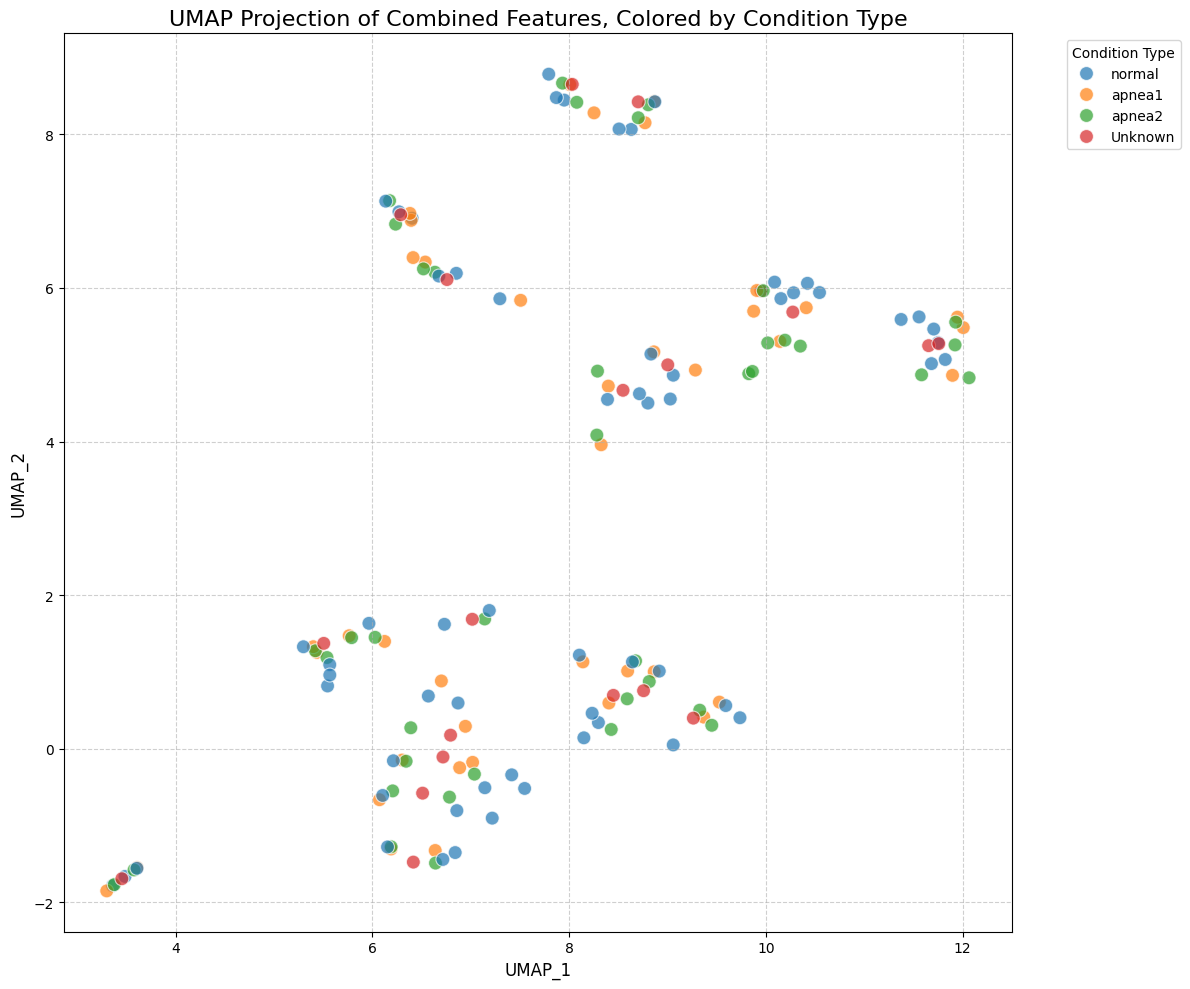

In [ ]:
import os

figures_dir = os.path.join(download_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP_1',
    y='UMAP_2',
    hue='condition_type',
    data=df_umap,
    s=100, # size of points
    alpha=0.7 # transparency
)

plt.title('UMAP Projection of Combined Features, Colored by Condition Type', fontsize=16)
plt.xlabel('UMAP_1', fontsize=12)
plt.ylabel('UMAP_2', fontsize=12)
plt.legend(title='Condition Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'umap_by_condition_type.png'))
plt.show()

We can also visualize the UMAP components colored by `pressure` to see if different pressure levels form distinct clusters.

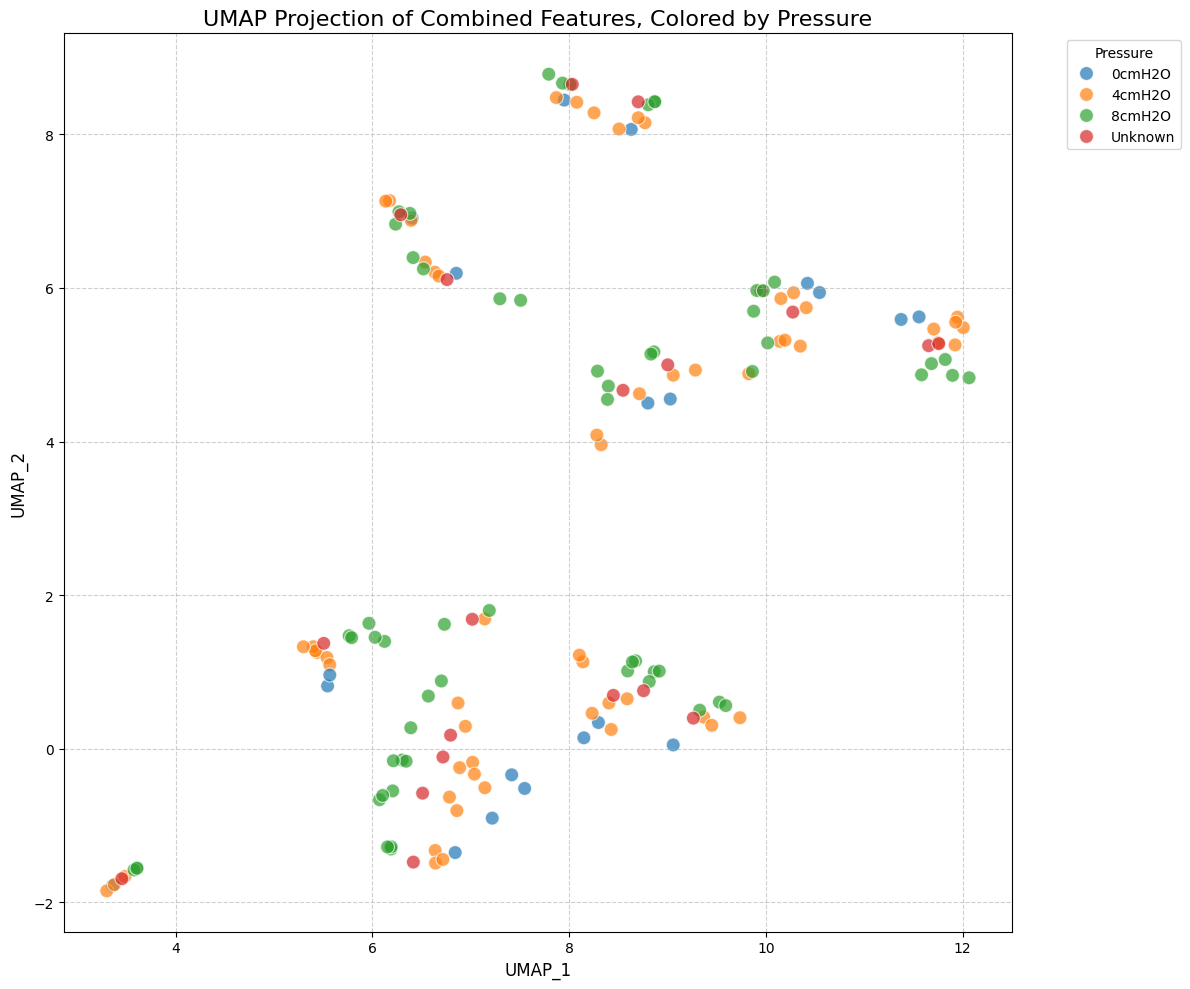

In [ ]:
import os

figures_dir = os.path.join(download_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP_1',
    y='UMAP_2',
    hue='pressure',
    data=df_umap,
    s=100,
    alpha=0.7
)

plt.title('UMAP Projection of Combined Features, Colored by Pressure', fontsize=16)
plt.xlabel('UMAP_1', fontsize=12)
plt.ylabel('UMAP_2', fontsize=12)
plt.legend(title='Pressure', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'umap_by_pressure.png'))
plt.show()

### Creating a Label for Classification

To prepare for potential classification tasks, we will create a new 'label' column in `df_final_merged_features`.
This label will categorize each entry as either 'apnea' or 'normal' based on the `condition_type`.

Entries with `condition_type` containing 'apnea' will be labeled as `1` (apnea), and 'normal' will be labeled as `0` (normal).
Other conditions like 'Baseline' or 'Unknown' will be handled separately (e.g., dropped or assigned a neutral label if needed).


In [ ]:
import numpy as np

# Create the 'label' column based on 'condition_type'
# 1 for apnea, 0 for normal, NaN for others (e.g., Baseline, Unknown)
df_final_merged_features['label'] = df_final_merged_features['condition_type'].apply(
    lambda x: 1 if 'apnea' in x else (0 if 'normal' in x else np.nan)
)

print("Distribution of the newly created 'label' column:")
display(df_final_merged_features['label'].value_counts(dropna=False))

df_final_merged_features.head()

Distribution of the newly created 'label' column:


label
1.0    80
0.0    60
NaN    20
Name: count, dtype: int64

,Gauge Pressure [cmH2O]_mean,Gauge Pressure [cmH2O]_std,Gauge Pressure [cmH2O]_min,Gauge Pressure [cmH2O]_max,Gauge Pressure [cmH2O]_median,Gauge Pressure [cmH2O]_variance,Gauge Pressure [cmH2O]_skew,Gauge Pressure [cmH2O]_kurtosis,Gauge Pressure [cmH2O]_peak_to_peak,Gauge Pressure [cmH2O]_rms,...,Neck Circumference [cm],BMI,Fitness Level (1-10)*,Average Trial SpaO2 [%],Average Trial HR [bpm],Asthma (Y/N),Smoker (Y/N),Vaper (Y/N),Unnamed: 13,label
0,-0.039046,0.157182,-0.85,0.76,0.00,0.024706,-0.506905,3.467608,1.61,0.161956,...,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN,0.0
1,2.533714,1.879277,0.00,8.46,3.65,3.531681,-0.344493,-1.097592,8.46,3.154564,...,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN,1.0
2,2.536226,1.881844,0.00,8.12,3.68,3.541338,-0.345236,-1.123369,8.12,3.158110,...,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN,1.0
3,2.632432,2.165442,0.00,10.79,3.47,4.689141,0.376715,0.094103,10.79,3.408619,...,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN,0.0
4,5.151464,3.665712,0.00,11.10,7.53,13.437442,-0.664069,-1.492127,11.10,6.322545,...,32.6,24.51,7.0,100.0,65.0,N,N,N,NaN,1.0


Now that the data has been merged with demographic information, we can save the final processed dataset.

In [ ]:
import os

output_filename = 'final_merged_features.csv'
output_path = os.path.join(download_dir, output_filename)

df_final_merged_features.to_csv(output_path, index=False)

print(f"Final merged features saved to: {output_path}")

Final merged features saved to: /content/downloaded_physionet_data/final_merged_features.csv


### Correlation Heatmap

To understand the relationships between the various numerical features, we will generate a correlation heatmap. This visualization helps to identify highly correlated features, which can be useful for feature selection or understanding data dependencies.

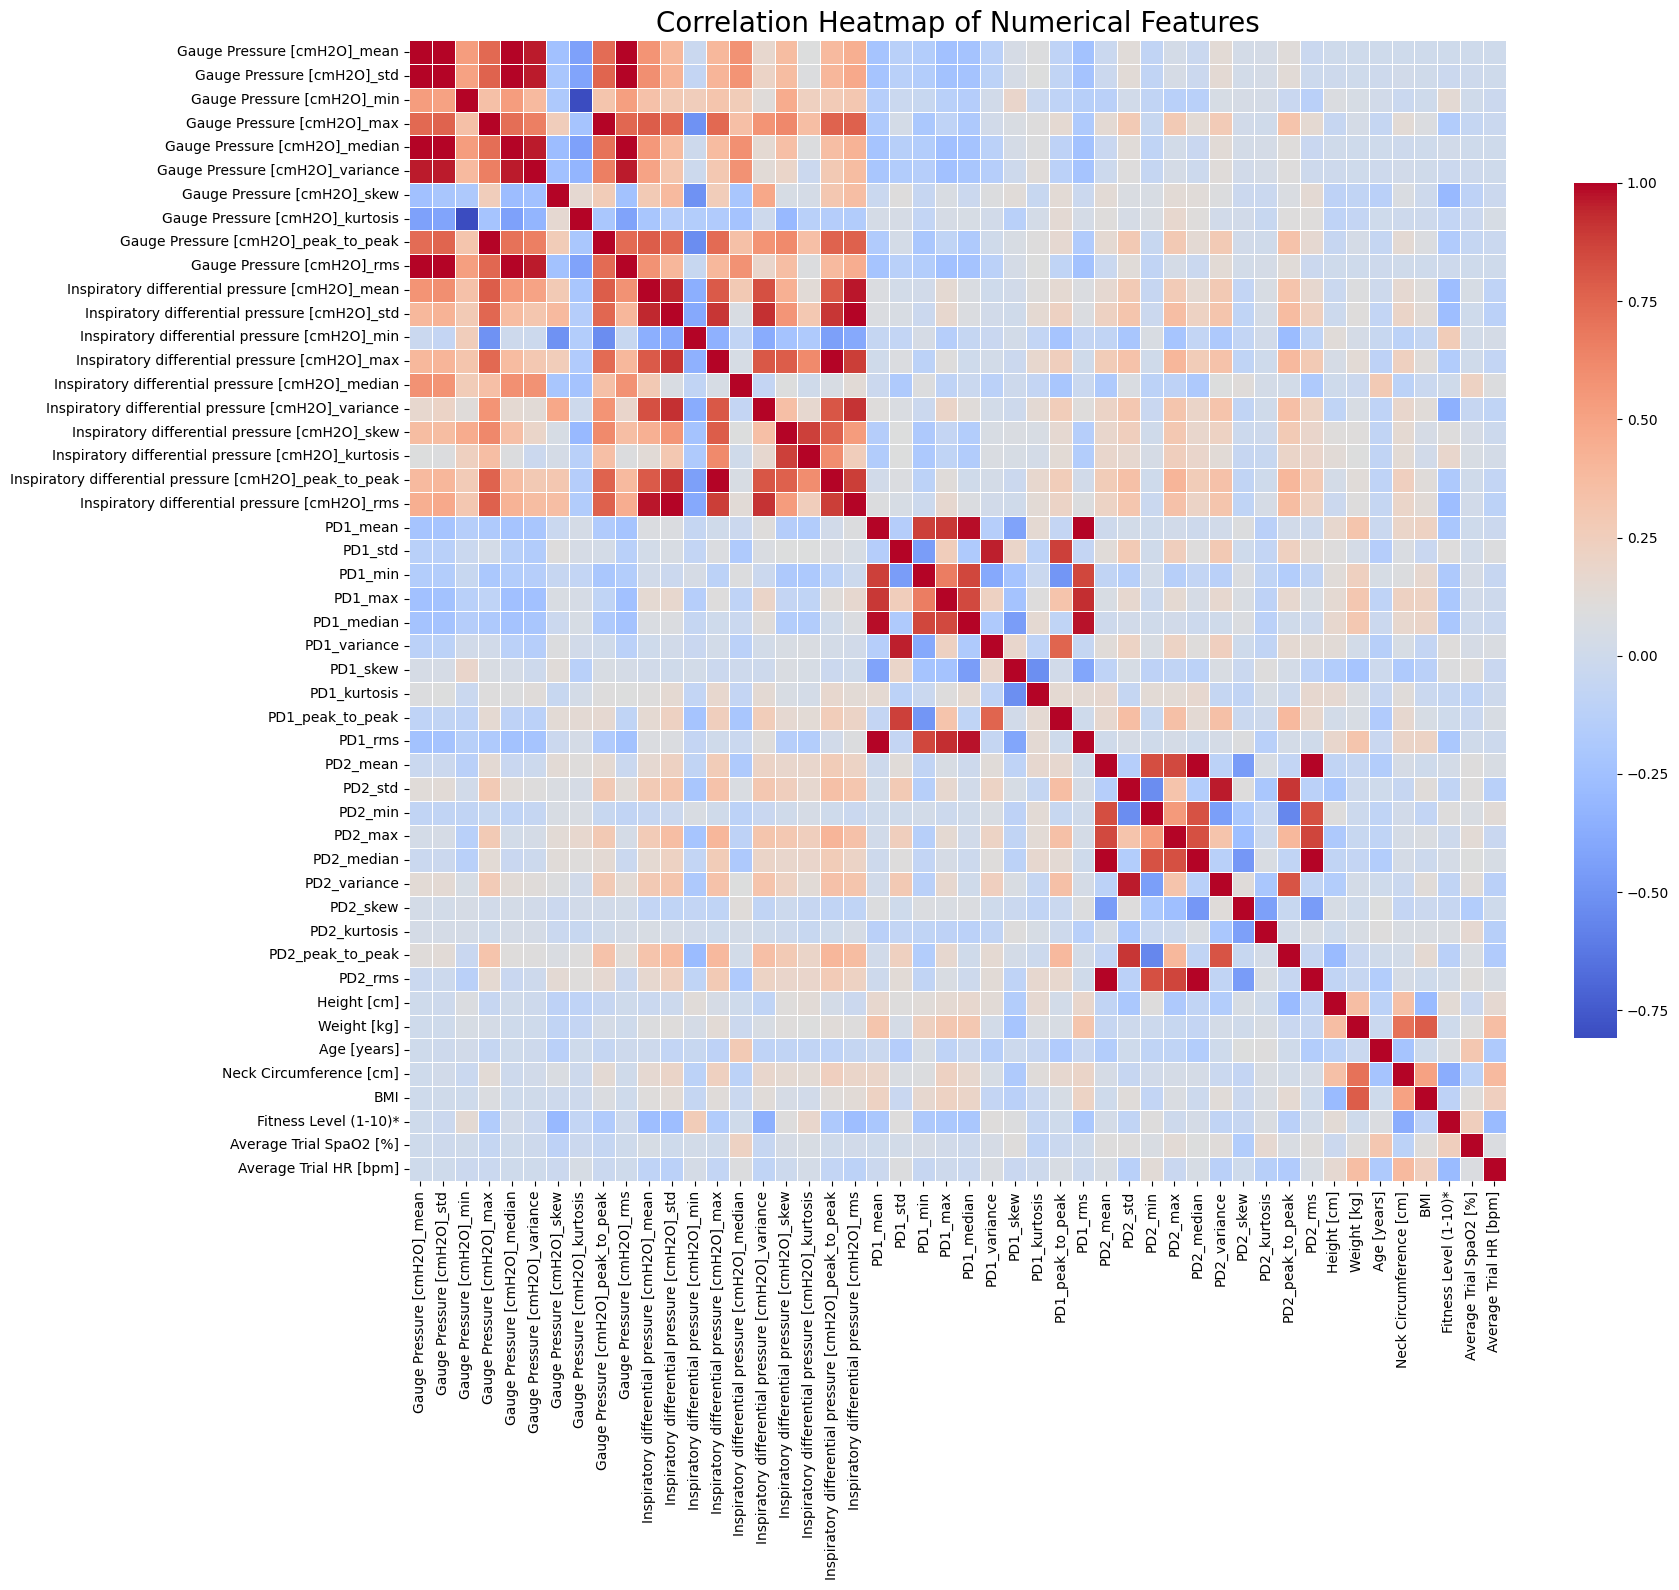

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

figures_dir = os.path.join(download_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)

# Calculate the correlation matrix for the numerical features
correlation_matrix = numerical_features_df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 16))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix,
            annot=False, # Set to True to show the correlation values on the heatmap
            cmap='coolwarm', # Color map for the heatmap
            fmt=".2f", # Format annotation values
            linewidths=.5, # Lines separating cells
            cbar_kws={'shrink': .75}) # Size of the color bar

plt.title('Correlation Heatmap of Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'correlation_heatmap.png'))
plt.show()

### Distribution of Average Trial SpO2

Let's visualize the distribution of the 'Average Trial SpaO2 [%]' to understand its statistical properties, such as central tendency, spread, and shape of the distribution.

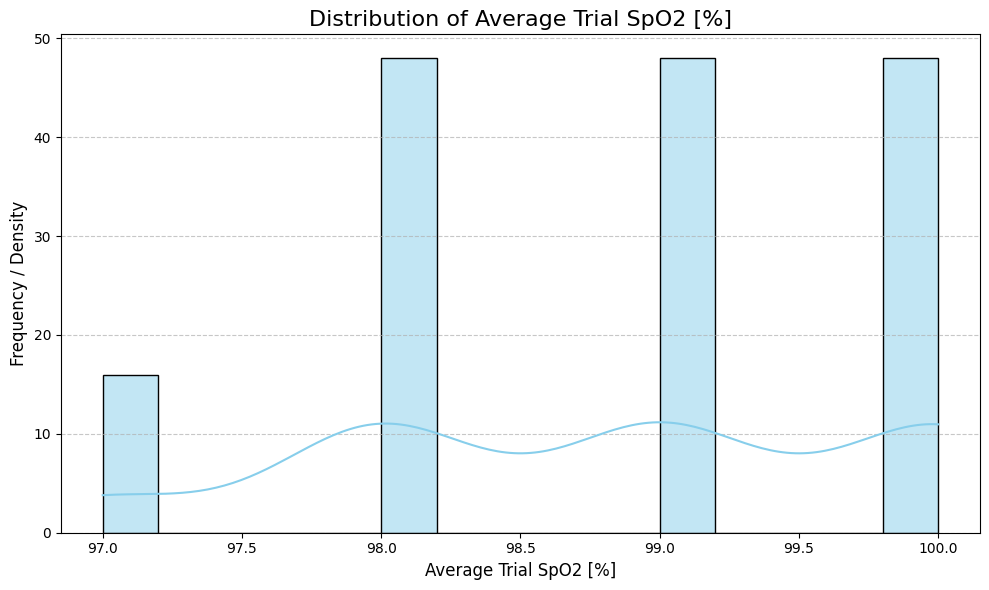

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

figures_dir = os.path.join(download_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)

# Check if the 'Average Trial SpaO2 [%]' column exists
if 'Average Trial SpaO2 [%]' in df_final_merged_features.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(
        df_final_merged_features['Average Trial SpaO2 [%]'].dropna(),
        kde=True, # Display Kernel Density Estimate
        bins=15, # Number of bins for the histogram
        color='skyblue', # Color of the bars
        edgecolor='black' # Edge color for the bars
    )
    plt.title('Distribution of Average Trial SpO2 [%]', fontsize=16)
    plt.xlabel('Average Trial SpO2 [%]', fontsize=12)
    plt.ylabel('Frequency / Density', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, 'distribution_avg_spo2.png'))
    plt.show()
elif 'Average Trial SpaO2' in df_final_merged_features.columns: # Check for column name without units
    plt.figure(figsize=(10, 6))
    sns.histplot(
        df_final_merged_features['Average Trial SpaO2'].dropna(),
        kde=True,
        bins=15,
        color='skyblue',
        edgecolor='black'
    )
    plt.title('Distribution of Average Trial SpO2', fontsize=16)
    plt.xlabel('Average Trial SpO2', fontsize=12)
    plt.ylabel('Frequency / Density', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, 'distribution_avg_spo2.png'))
    plt.show()
else:
    print("Column 'Average Trial SpaO2 [%]' or 'Average Trial SpaO2' not found in the DataFrame.")
    print("Available columns are:")
    for col in df_final_merged_features.columns:
        print(f"- {col}")

### Comparing Apnea vs Normal using UMAP

Now, let's visualize the UMAP components, colored by our newly created 'label' column (0 for normal, 1 for apnea), to see how well these two conditions are separated in the reduced-dimension space. This can provide insights into the distinctness of these physiological states based on the extracted features.

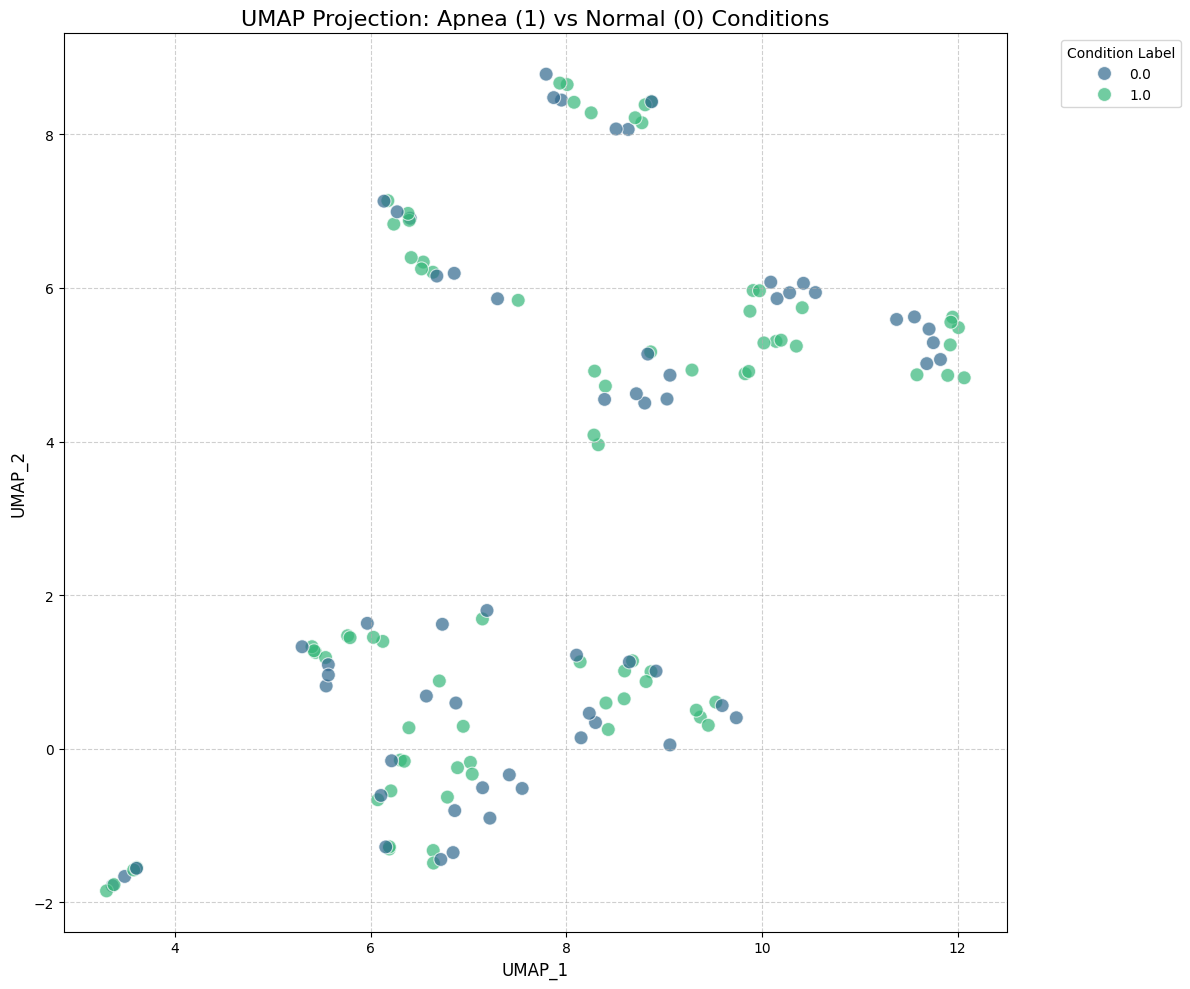

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

figures_dir = os.path.join(download_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)

# Join the 'label' column to the df_umap DataFrame for visualization
df_umap_labeled = pd.merge(
    df_umap,
    df_final_merged_features[['subject_id', 'pressure', 'condition_type', 'label']],
    on=['subject_id', 'pressure', 'condition_type'],
    how='left'
)

# Filter out NaN labels if any for visualization clarity
df_umap_labeled_filtered = df_umap_labeled.dropna(subset=['label'])

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP_1',
    y='UMAP_2',
    hue='label',
    data=df_umap_labeled_filtered,
    s=100, # size of points
    alpha=0.7, # transparency
    palette='viridis' # Color palette
)

plt.title('UMAP Projection: Apnea (1) vs Normal (0) Conditions', fontsize=16)
plt.xlabel('UMAP_1', fontsize=12)
plt.ylabel('UMAP_2', fontsize=12)
plt.legend(title='Condition Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'umap_apnea_vs_normal.png'))
plt.show()

### 3D UMAP Dimensionality Reduction

To further explore the data structure, we will perform UMAP dimensionality reduction with three components. This will allow for a 3D visualization, potentially revealing additional insights into how the different conditions and pressures separate in a higher-dimensional reduced space.

In [ ]:
import umap
import pandas as pd
import plotly.express as px

# Initialize UMAP reducer for 3 components
reducer_3d = umap.UMAP(n_components=3, random_state=42)

# Fit and transform the data
umap_embedding_3d = reducer_3d.fit_transform(numerical_features_df)

# Create a DataFrame for the 3D UMAP embedding
df_umap_3d = pd.DataFrame(umap_embedding_3d, columns=['UMAP_1', 'UMAP_2', 'UMAP_3'])

# Add back relevant metadata for visualization
df_umap_3d['subject_id'] = df_final_merged_features['subject_id']
df_umap_3d['pressure'] = df_final_merged_features['pressure']
df_umap_3d['condition_type'] = df_final_merged_features['condition_type']
df_umap_3d['label'] = df_final_merged_features['label']

print("3D UMAP dimensionality reduction complete.")
print(f"Shape of 3D UMAP embedding: {df_umap_3d.shape}")
display(df_umap_3d.head())

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


3D UMAP dimensionality reduction complete.
Shape of 3D UMAP embedding: (160, 7)


,UMAP_1,UMAP_2,UMAP_3,subject_id,pressure,condition_type,label
0,6.890318,1.404855,2.885819,Subject1,0cmH2O,normal,0.0
1,7.397927,1.419010,3.126548,Subject1,4cmH2O,apnea1,1.0
2,9.045323,2.056366,2.596092,Subject1,4cmH2O,apnea2,1.0
3,7.968838,1.563588,3.264275,Subject1,4cmH2O,normal,0.0
4,8.227851,1.514430,3.220352,Subject1,8cmH2O,apnea1,1.0


### Visualize 3D UMAP Embedding

Now we'll visualize the 3D UMAP components. We can use a scatter plot, colored by the 'label' (apnea vs normal), to see if there are clearer separations in three dimensions.

In [ ]:
import plotly.express as px
import os

figures_dir = os.path.join(download_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)

# Filter out NaN labels for visualization clarity
df_umap_3d_filtered = df_umap_3d.dropna(subset=['label'])

# Create a 3D scatter plot using Plotly Express
fig = px.scatter_3d(
    df_umap_3d_filtered,
    x='UMAP_1',
    y='UMAP_2',
    z='UMAP_3',
    color='label',
    color_continuous_scale=px.colors.sequential.Viridis,
    title='3D UMAP Projection: Apnea (1) vs Normal (0) Conditions'
)

fig.update_layout(scene = dict(
                    xaxis_title='UMAP_1',
                    yaxis_title='UMAP_2',
                    zaxis_title='UMAP_3'))

fig.show()

# Plotly figures can be saved as HTML or static images (e.g., PNG/JPEG/SVG if `kaleido` is installed)
# For a static PNG, you would typically need `pip install kaleido`
# fig.write_image(os.path.join(figures_dir, 'umap_3d_apnea_vs_normal.png'))
print(f"Interactive 3D UMAP plot displayed above. To save as a static image, install `kaleido` (`pip install kaleido`) and uncomment the `fig.write_image` line.")

Interactive 3D UMAP plot displayed above. To save as a static image, install `kaleido` (`pip install kaleido`) and uncomment the `fig.write_image` line.


### Train/Test Split for Machine Learning

To prepare the data for training a machine learning model, we need to split it into training and testing sets. The training set will be used to teach the model, and the testing set will be used to evaluate its performance on unseen data. We will use the `label` column as our target variable (`y`) and the `numerical_features_df` as our feature set (`X`). Entries with a `NaN` label will be excluded from the split.

Machine Learning Models

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define features (X) and target (y)
# We'll use numerical_features_df which has already handled NaNs for features.
# Align X with the df_final_merged_features based on index to ensure correct label matching.
X = numerical_features_df.copy()
y = df_final_merged_features['label'].copy()

# Combine X and y to easily drop rows where the label is NaN
df_for_split = pd.concat([X, y], axis=1)
df_for_split = df_for_split.dropna(subset=['label'])

# Separate X and y again after dropping NaNs
X_split = df_for_split.drop(columns=['label'])
y_split = df_for_split['label']

# Perform the train-test split
# Using a common random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_split, y_split, test_size=0.2, random_state=42, stratify=y_split)

print(f"Original dataset size: {len(X)}")
print(f"Dataset size after dropping NaN labels: {len(X_split)}")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of labels in training set:")
display(y_train.value_counts())
print("\nDistribution of labels in test set:")
display(y_test.value_counts())

Original dataset size: 160
Dataset size after dropping NaN labels: 140
Shape of X_train: (112, 48)
Shape of X_test: (28, 48)
Shape of y_train: (112,)
Shape of y_test: (28,)

Distribution of labels in training set:


label
1.0    64
0.0    48
Name: count, dtype: int64


Distribution of labels in test set:


label
1.0    16
0.0    12
Name: count, dtype: int64

### Random Forest Classifier

Now, we'll train a Random Forest Classifier on our data. Random Forest is an ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. We will evaluate its performance using common classification metrics.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize the Random Forest Classifier
# Using a random_state for reproducibility
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training Random Forest Classifier...")
# Train the model
random_forest_model.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"\nRandom Forest Classifier Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Training Random Forest Classifier...
Training complete.

Random Forest Classifier Performance:
Accuracy: 0.9286
Precision: 0.9375
Recall: 0.9375
F1-Score: 0.9375

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.92      0.92        12
         1.0       0.94      0.94      0.94        16

    accuracy                           0.93        28
   macro avg       0.93      0.93      0.93        28
weighted avg       0.93      0.93      0.93        28



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = random_forest_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[11  1]
 [ 1 15]]
              precision    recall  f1-score   support

         0.0       0.92      0.92      0.92        12
         1.0       0.94      0.94      0.94        16

    accuracy                           0.93        28
   macro avg       0.93      0.93      0.93        28
weighted avg       0.93      0.93      0.93        28



### Feature Importance from Random Forest Model

Understanding feature importance helps us identify which input variables the model considers most significant for making predictions. For a Random Forest Classifier, this is typically measured by the decrease in node impurity attributed to each feature (e.g., Gini impurity or entropy). Let's extract and visualize the top features.

/tmp/ipykernel_2121/917055368.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=df_feature_importances.head(N), palette='viridis')


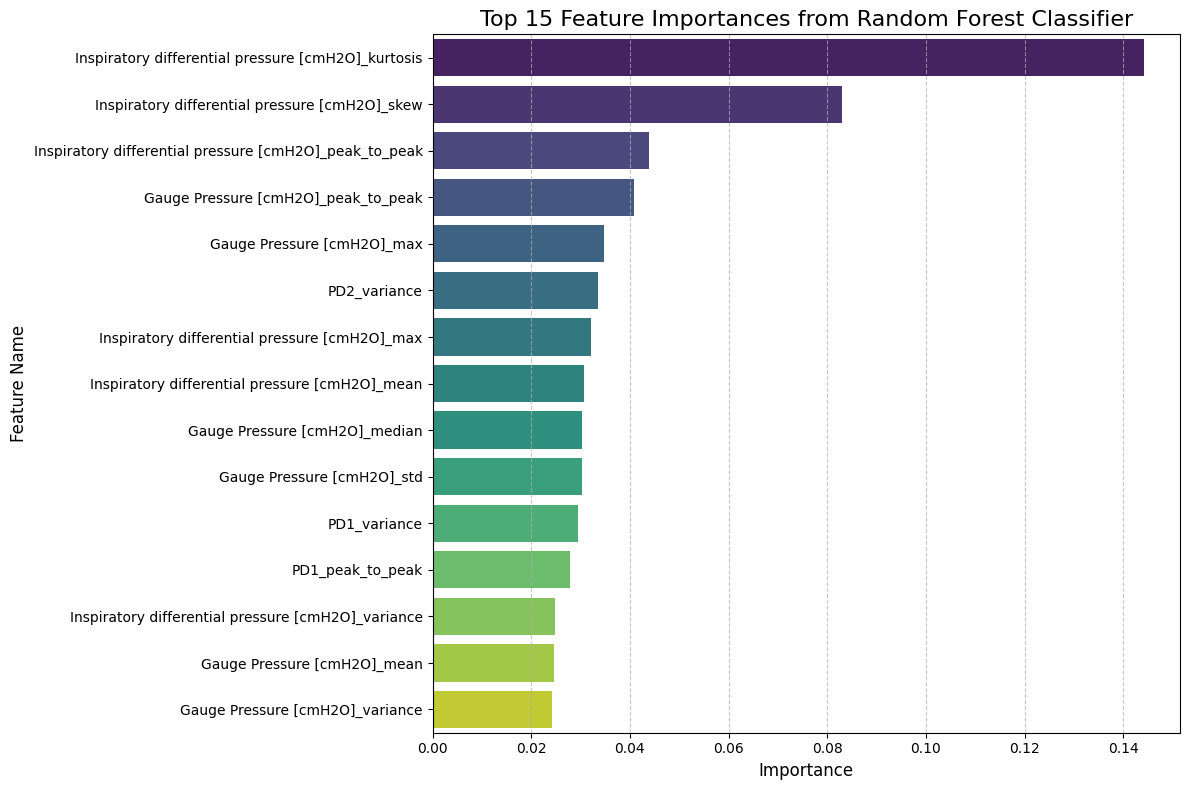

,feature,importance
17,Inspiratory differential pressure [cmH2O]_kurt...,0.144296
16,Inspiratory differential pressure [cmH2O]_skew,0.083014
18,Inspiratory differential pressure [cmH2O]_peak...,0.043959
8,Gauge Pressure [cmH2O]_peak_to_peak,0.040857
3,Gauge Pressure [cmH2O]_max,0.034747
35,PD2_variance,0.033487
13,Inspiratory differential pressure [cmH2O]_max,0.032150
10,Inspiratory differential pressure [cmH2O]_mean,0.030697
4,Gauge Pressure [cmH2O]_median,0.030385
1,Gauge Pressure [cmH2O]_std,0.030201


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

figures_dir = os.path.join(download_dir, 'figures')
os.makedirs(figures_dir, exist_ok=True)

# Get feature importances from the trained Random Forest model
feature_importances = random_forest_model.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
df_feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})

# Sort features by importance in descending order
df_feature_importances = df_feature_importances.sort_values(by='importance', ascending=False)

# Display the top N features (e.g., top 15)
N = 15
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=df_feature_importances.head(N), palette='viridis')
plt.title(f'Top {N} Feature Importances from Random Forest Classifier', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'top_feature_importances.png'))
plt.show()

display(df_feature_importances.head(N))

Compare Multimodal vs Single Modal

In [ ]:
# Respiratory only
resp_cols = [col for col in X.columns if "Gauge Pressure" in col or "Inspiratory differential pressure" in col]

model_resp = RandomForestClassifier()
model_resp.fit(X_train[resp_cols], y_train)

print("Resp Only:")
print(classification_report(y_test, model_resp.predict(X_test[resp_cols])))

Resp Only:
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89        12
         1.0       1.00      0.81      0.90        16

    accuracy                           0.89        28
   macro avg       0.90      0.91      0.89        28
weighted avg       0.91      0.89      0.89        28



In [ ]:
# Oximetry
oxims_cols = [col for col in X.columns if "PD1" in col or "PD2" in col]
model_oxims = RandomForestClassifier()
model_oxims.fit(X_train[oxims_cols], y_train)

print("Oximetry Only:")
print(classification_report(y_test, model_oxims.predict(X_test[oxims_cols])))

Oximetry Only:
              precision    recall  f1-score   support

         0.0       0.50      0.42      0.45        12
         1.0       0.61      0.69      0.65        16

    accuracy                           0.57        28
   macro avg       0.56      0.55      0.55        28
weighted avg       0.56      0.57      0.56        28



Multimodal

In [ ]:
print("Multimodal:")
print(classification_report(y_test, y_pred))

Multimodal:
              precision    recall  f1-score   support

         0.0       0.92      0.92      0.92        12
         1.0       0.94      0.94      0.94        16

    accuracy                           0.93        28
   macro avg       0.93      0.93      0.93        28
weighted avg       0.93      0.93      0.93        28

